# Retrieval-система по статьям с arXiv

**Цель:** построение системы поиска с MRR@5 > 0.91. 

**Датасет:** метаданные статей `arxiv-metadata-s.json` и набор тестовых запросов для оценки качества поиска `test_sample.csv`.

In [1]:
import json
import pandas as pd
import numpy as np
import time
import faiss
import torch
import warnings
from datetime import datetime
from tqdm.auto import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from langchain_core.documents import Document
from langchain_text_splitters.character import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

warnings.filterwarnings('ignore')

/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Настройка cuda

def setup_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Используется CUDA: {torch.cuda.get_device_name()}")
    else:
        device = torch.device("cpu")
        print("Используется CPU")
    
    # Оптимизации для CPU
    if device.type == "cpu":
        usfull_threads = os.cpu_count() - 2
        os.environ["OMP_NUM_THREADS"] = str(usfull_threads)
        os.environ["MKL_NUM_THREADS"] = str(usfull_threads)
    
    return device

# Инициализация устройства
device = setup_device()

Используется CUDA: Tesla T4


## Этап 0. Загрузка данных

In [3]:
def load_arxiv_data(file_path, max_docs=100000):
    data = []
    print(f"Загрузка данных из {file_path}...")
    
    with open(file_path, 'r', encoding='utf-8') as f:
        articles = json.load(f)
        
    for i, item in tqdm(enumerate(articles), total=min(max_docs, len(articles)), desc='Загрузка документов'):
        if i >= max_docs:
            break
        try:
            # Создаем документы для langchain
            metadata = {
                'id': item.get('id', ''),
                'title': item.get('title', ''),
                'categories': item.get('categories', ''),
                'authors': ', '.join([f"{author[0]} {author[1]}" for author in item.get('authors_parsed', [])]),
                'update_date': item.get('update_date', ''),
                'journal_ref': item.get('journal-ref', ''),
                'doi': item.get('doi', '')
            }
            
            # Комбинируем заголовок и аннотацию для лучшего поиска
            content = f"Title: {item.get('title', '')}\nAbstract: {item.get('abstract', '')}"
            
            data.append(Document(
                page_content=content,
                metadata=metadata
            ))
        except Exception as e:
            continue
    
    return data


In [4]:
# Загрузка тестовых данных
test_df = pd.read_csv(r'nlp_s3_project/test_sample.csv')
print(f'Тестовые данные: {test_df.shape}')
arxiv_documents = load_arxiv_data(r'nlp_s3_project/arxiv-metadata-s.json', max_docs=150000)
print(f'Загружено {len(arxiv_documents)} документов')

Тестовые данные: (1000, 3)
Загрузка данных из nlp_s3_project/arxiv-metadata-s.json...


Загрузка документов: 100%|██████████| 98213/98213 [00:00<00:00, 99324.46it/s] 

Загружено 98213 документов


# Этап 1. EDA

### Изучим датасеты

In [5]:
# Изучим датасет arXiv 
arxiv_df = pd.read_json(
    r'nlp_s3_project/arxiv-metadata-s.json'
)

print(arxiv_df.shape)
arxiv_df.head()


(98213, 14)


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0038,Maxim A. Yurkin,"Maxim A. Yurkin, Alfons G. Hoekstra",The discrete dipole approximation: an overview...,"36 pages, 1 figure; added several corrections ...","J.Quant.Spectrosc.Radiat.Transf. 106, 558-589 ...",10.1016/j.jqsrt.2007.01.034 10.1016/j.jqsrt.20...,None,physics.optics physics.comp-ph,http://creativecommons.org/licenses/by-nc-nd/4.0/,We present a review of the discrete dipole a...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2022-03-30,"[[Yurkin, Maxim A., ], [Hoekstra, Alfons G., ]]"
1,0704.0057,Philipp Werner,Philipp Werner and Andrew J. Millis,High-spin to low-spin and orbital polarization...,Published version,"Phys. Rev. Lett. 99, 126405 (2007)",10.1103/PhysRevLett.99.126405,None,cond-mat.str-el,None,We study the interplay of crystal field spli...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2009-11-13,"[[Werner, Philipp, ], [Millis, Andrew J., ]]"
2,0704.0060,Carlos Bertulani,"C.A. Bertulani, G. Cardella, M. De Napoli, G. ...",Coulomb excitation of unstable nuclei at inter...,"12 pages, 2 figures, accepted for publication ...","Phys.Lett.B650:233-238,2007",10.1016/j.physletb.2007.05.029,None,nucl-th,None,We investigate the Coulomb excitation of low...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-11-26,"[[Bertulani, C. A., ], [Cardella, G., ], [De N..."
3,0704.0070,Yanzhang He,He Yanzhang and Bao Chengguang,Coincidence of the oscillations in the dipole ...,"5 pages, 4 figures, submitted",J. Phys.: Condens. Matter 20 (2008) 055214,None,None,cond-mat.mes-hall,None,The fractional Aharonov-Bohm oscillation (FA...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-19,"[[Yanzhang, He, ], [Chengguang, Bao, ]]"
4,0704.0074,Jawad Y. Abuhlail,"J. Y. Abuhlail, S. K. Nauman",Injective Morita contexts (revisited),None,None,None,None,math.RA,None,This paper is an exposition of the so-called...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2007-08-22,"[[Abuhlail, J. Y., ], [Nauman, S. K., ]]"


In [6]:
# Изучим тестовый датасет 
test_df = pd.read_csv(r'nlp_s3_project/test_sample.csv')

print(test_df.shape)
test_df.head()

(1000, 3)


,id,abstract,query
0,2412.16732,A new platinate was recently discovered when...,What unique composition and decomposition beha...
1,nucl-th/9602019,The production cross sections of various fra...,How does the inclusion of statistical decay af...
2,2501.05500,This survey provides a comprehensive examina...,What are the core components of modern zero-kn...
3,2506.20892,A critical challenge for operating fusion burn...,How does impurity seeding affect the timing an...
4,2208.02031,"In this work, we present the first corpus fo...",What is the primary challenge of the newly dev...


Средняя длина запроса: 126.9 символов
Максимальная длина запроса: 238 символов


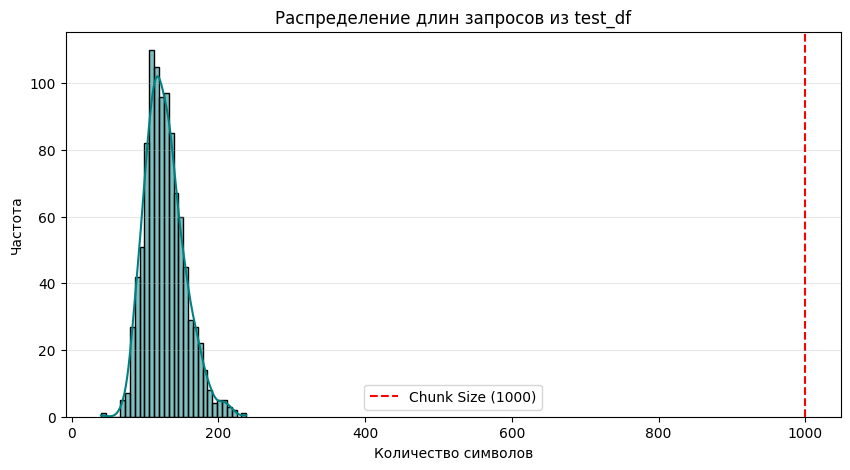

Все запросы умещаются в размер одного чанка. Параметры выбраны корректно.


In [7]:
# Сопоставление длины запросов с размером чанка

test_df['query_len'] = test_df['query'].apply(len)

# Рассчитываем основные метрики
mean_len = test_df['query_len'].mean()
max_len = test_df['query_len'].max()
chunk_size_limit = 1000 

print(f'Средняя длина запроса: {mean_len:.1f} символов')
print(f'Максимальная длина запроса: {max_len} символов')

plt.figure(figsize=(10, 5))
sns.histplot(test_df['query_len'], bins=30, kde=True, color='teal')

# визуализируем
plt.axvline(chunk_size_limit, color='red', linestyle='--', label=f'Chunk Size ({chunk_size_limit})')

plt.title('Распределение длин запросов из test_df')
plt.xlabel('Количество символов')
plt.ylabel('Частота')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Проверка
if max_len > chunk_size_limit:
    print(f'Есть запросы длиннее чанка ({max_len} > {chunk_size_limit}). '
          'Это может снизить качество поиска.')
else:
    print('Все запросы умещаются в размер одного чанка. Параметры выбраны корректно.')

In [8]:
# Статистическая выгрузка для датасетов
from IPython.display import display

HEAVY_OBJECT_COLS = {'abstract', 'versions', 'authors_parsed', 'authors', 'comments'}

def show_dataset_stats(name, df):
    print(f'{name}: shape = {df.shape}')
    
    print('\nINFO')
    df.info()
    
    # describe для числовых колонок
    numeric_cols = df.select_dtypes(include='number').columns
    if len(numeric_cols) > 0:
        print('\nDESCRIBE')
        display(df[numeric_cols].describe().T)
    else:
        print('\nDESCRIBE: числовых колонок нет')
    
    object_cols = [
        col for col in df.select_dtypes(include='object').columns
        if col not in HEAVY_OBJECT_COLS
    ]
    if len(object_cols) > 0:
        print('\nOBJECT OVERVIEW')
        object_stats = pd.DataFrame({
            'count': df[object_cols].count(),
            'missing': df[object_cols].isna().sum(),
            'missing_pct': (df[object_cols].isna().mean() * 100).round(2),
            'unique': df[object_cols].nunique(dropna=True)
        })
        display(object_stats)
    else:
        print('\nOBJECT OVERVIEW: легких object-колонок нет')
    
    print('\nNULLS / UNIQUE VALUES')
    light_unique_cols = [col for col in df.columns if col not in HEAVY_OBJECT_COLS]
    unique_counts = pd.Series('skipped', index=df.columns, dtype='object')
    unique_counts.loc[light_unique_cols] = df[light_unique_cols].nunique(dropna=True)
    missing_stats = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
        'unique': unique_counts
    }).sort_values('missing_pct', ascending=False)
    display(missing_stats)
    
    text_cols = [col for col in object_cols if col not in HEAVY_OBJECT_COLS]
    if len(text_cols) > 0:
        print('\nTEXT LENGTH STATS')
        text_length_stats = pd.DataFrame({
            col: df[col].dropna().astype(str).str.len().describe()
            for col in text_cols
        }).T
        display(text_length_stats)

show_dataset_stats('arxiv_df', arxiv_df)
show_dataset_stats('test_df', test_df)

arxiv_df: shape = (98213, 14)

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98213 entries, 0 to 98212
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              98213 non-null  object
 1   submitter       97650 non-null  object
 2   authors         98213 non-null  object
 3   title           98213 non-null  object
 4   comments        72275 non-null  object
 5   journal-ref     31672 non-null  object
 6   doi             43744 non-null  object
 7   report-no       6558 non-null   object
 8   categories      98213 non-null  object
 9   license         82351 non-null  object
 10  abstract        98213 non-null  object
 11  versions        98213 non-null  object
 12  update_date     98213 non-null  object
 13  authors_parsed  98213 non-null  object
dtypes: object(14)
memory usage: 10.5+ MB

DESCRIBE: числовых колонок нет

OBJECT OVERVIEW


,count,missing,missing_pct,unique
id,98213,0,0.00,98213
submitter,97650,563,0.57,76466
title,98213,0,0.00,98204
journal-ref,31672,66541,67.75,31615
doi,43744,54469,55.46,43736
report-no,6558,91655,93.32,6457
categories,98213,0,0.00,11064
license,82351,15862,16.15,9
update_date,98213,0,0.00,4841



NULLS / UNIQUE VALUES


,dtype,missing,missing_pct,unique
report-no,object,91655,93.32,6457
journal-ref,object,66541,67.75,31615
doi,object,54469,55.46,43736
comments,object,25938,26.41,skipped
license,object,15862,16.15,9
submitter,object,563,0.57,76466
authors,object,0,0.00,skipped
title,object,0,0.00,98204
id,object,0,0.00,98213
categories,object,0,0.00,11064



TEXT LENGTH STATS


...

,count,missing,missing_pct,unique
id,1000,0,0.0,1000
query,1000,0,0.0,1000



NULLS / UNIQUE VALUES


,dtype,missing,missing_pct,unique
id,object,0,0.0,1000
abstract,object,0,0.0,skipped
query,object,0,0.0,1000
query_len,int64,0,0.0,134



TEXT LENGTH STATS


,count,mean,std,min,25%,50%,75%,max
id,1000.0,10.447,1.816725,9.0,10.0,10.0,10.0,16.0
query,1000.0,126.886,26.951909,40.0,108.0,123.5,143.0,238.0


На основе предоставленных данных можно составить следующее описание наборов данных:

1. Основной датасет (arxiv_df)
Это корпус метаданных научных статей arXiv, содержащий 98 213 записей и 14 признаков.

Все колонки имеют строковый тип (object). Числовых данных в исходном виде нет.

Поле id является уникальным ключом для каждой статьи (98 213 уникальных значений).

Пропуски в данных:
Почти отсутствуют данные в report-no (93% пропусков) и journal-ref (68% пропусков).
Частичные пропуски: в поле doi (идентификатор цифрового объекта) отсутствует 55% данных, в comments — 26%, в license — 16%.

Заголовки (title): Средняя длина составляет 75 символов. Почти все заголовки уникальны (98 204), что говорит о минимальном количестве дублей.


2. Тестовый датасет (test_df)
Этот набор данных предназначен для оценки качества поисковой системы (Retrieval). Он содержит 1 000 примеров.

Состоит из трех колонок: id, abstract (аннотация статьи) и query (поисковый запрос).

Пропуски отсутствуют. Все идентификаторы и запросы уникальны.

### Изучим документы в arhiv

In [9]:
doc_titles_len = [len(doc.metadata['title']) for doc in arxiv_documents]
doc_abstracts_len = [len(doc.page_content.replace(f"Title: {doc.metadata['title']}\nAbstract: ", "")) for doc in arxiv_documents]
all_categories = [cat for doc in arxiv_documents for cat in doc.metadata['categories'].split()]

print(f'\nДокументов в базе: {len(arxiv_documents)}')


Документов в базе: 98213


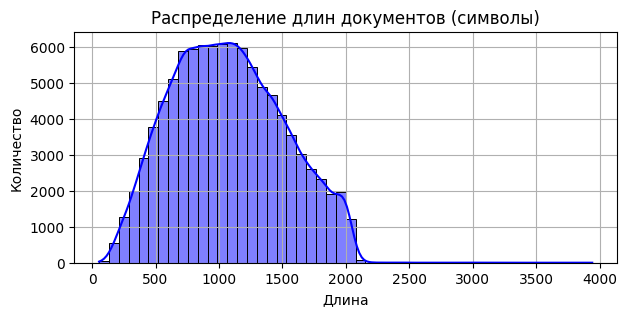

In [10]:
# 1. Длина документов arhiv
doc_lengths = [len(doc.page_content) for doc in arxiv_documents]

plt.figure(figsize=(7, 3))
sns.histplot(doc_lengths, bins=50, kde=True, color='blue')
plt.title('Распределение длин документов (символы)')
plt.xlabel('Длина')
plt.ylabel('Количество')
plt.grid()
plt.show()

#### Заголовки

In [11]:
print(f'Средняя длина заголовка: {np.mean(doc_titles_len):.1f} символов')
print(f'Минимальная длина заголовка: {np.min(doc_titles_len):.1f} символов')
print(f'Максимальная длина заголовка: {np.max(doc_titles_len):.1f} символов')

Средняя длина заголовка: 75.2 символов
Минимальная длина заголовка: 7.0 символов
Максимальная длина заголовка: 381.0 символов


Text(0.5, 0, 'Символы')

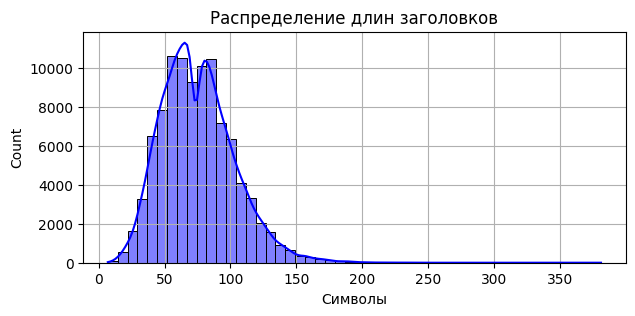

In [12]:
# визуализируем
plt.figure(figsize=(7, 3))
sns.histplot(doc_titles_len, bins=50, color='blue', kde=True)
plt.grid()
plt.title('Распределение длин заголовков')
plt.xlabel('Символы')

#### Аннотации

In [13]:
print(f'Средняя длина аннотации: {np.mean(doc_abstracts_len):.1f} символов')
print(f'Минимальная длина аннотации: {np.min(doc_abstracts_len):.1f} символов')
print(f'Максимальная длина аннотации: {np.max(doc_abstracts_len):.1f} символов')

Средняя длина аннотации: 981.9 символов
Минимальная длина аннотации: 21.0 символов
Максимальная длина аннотации: 3874.0 символов


Text(0.5, 0, 'Символы')

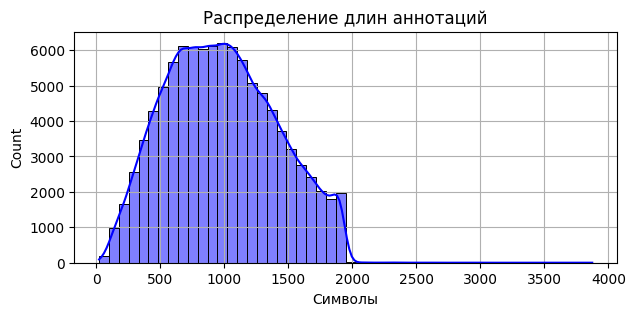

In [14]:
# визуализируем
plt.figure(figsize=(7, 3))
sns.histplot(doc_abstracts_len, bins=50, color='blue', kde=True)
plt.grid()
plt.title('Распределение длин аннотаций')
plt.xlabel('Символы')

#### Тестовая выборка

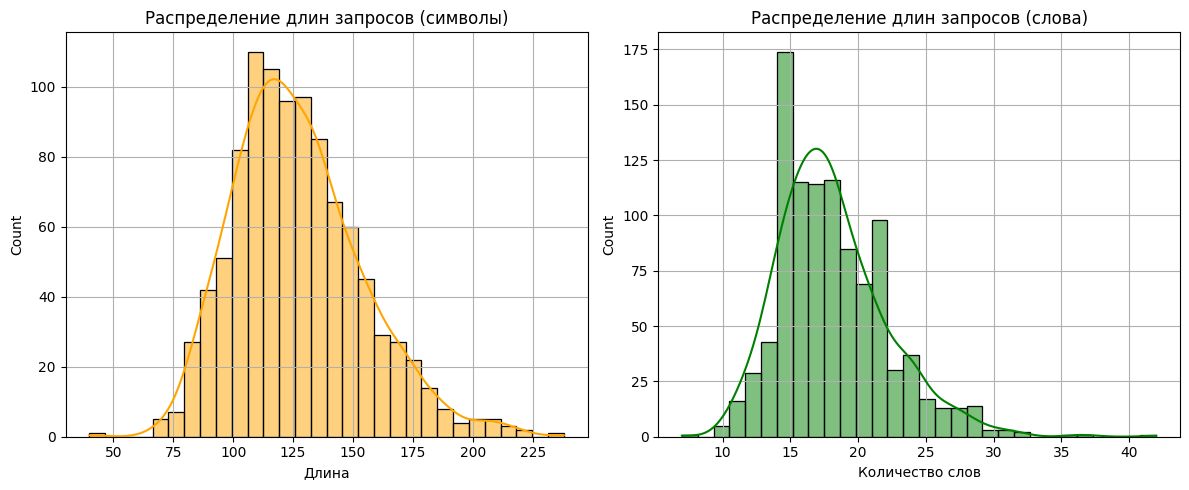

Средняя длина запроса: 126.9 символов


In [15]:
test_df['query_len'] = test_df['query'].apply(len)
test_df['query_word_count'] = test_df['query'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))

# Символы
plt.subplot(1, 2, 1)
sns.histplot(test_df['query_len'], bins=30, kde=True, color='orange')
plt.title('Распределение длин запросов (символы)')
plt.xlabel('Длина')
plt.grid()

# Слова
plt.subplot(1, 2, 2)
sns.histplot(test_df['query_word_count'], bins=30, kde=True, color='green')
plt.title('Распределение длин запросов (слова)')
plt.xlabel('Количество слов')
plt.grid()

plt.tight_layout()
plt.show()

print(f"Средняя длина запроса: {test_df['query_len'].mean():.1f} символов")

#### Категории

In [16]:
# Категории
cat_counts_all = Counter(all_categories)
cat_df = pd.DataFrame.from_dict(cat_counts_all, orient='index', columns=['count']).reset_index()
cat_df.columns = ['category', 'count']
cat_df = cat_df.sort_values('count', ascending=False).reset_index(drop=True)

total_mentions = cat_df['count'].sum()
cat_df['percentage'] = (cat_df['count'] / total_mentions * 100).round(2)

print(f'Количество категорий в датасете: {len(cat_df)}')

cat_df

Количество категорий в датасете: 174


,category,count,percentage
0,cs.LG,8152,4.82
1,hep-ph,6692,3.95
2,hep-th,6111,3.61
3,quant-ph,5783,3.42
4,cs.CV,5668,3.35
...,...,...,...
169,atom-ph,6,0.00
170,supr-con,6,0.00
171,chem-ph,5,0.00
172,mtrl-th,5,0.00


In [17]:
# Топ-15 категорий 
cat_df.head(15)

,category,count,percentage
0,cs.LG,8152,4.82
1,hep-ph,6692,3.95
2,hep-th,6111,3.61
3,quant-ph,5783,3.42
4,cs.CV,5668,3.35
5,cs.AI,4842,2.86
6,gr-qc,4096,2.42
7,astro-ph,3754,2.22
8,cond-mat.mtrl-sci,3634,2.15
9,cond-mat.mes-hall,3380,2.00


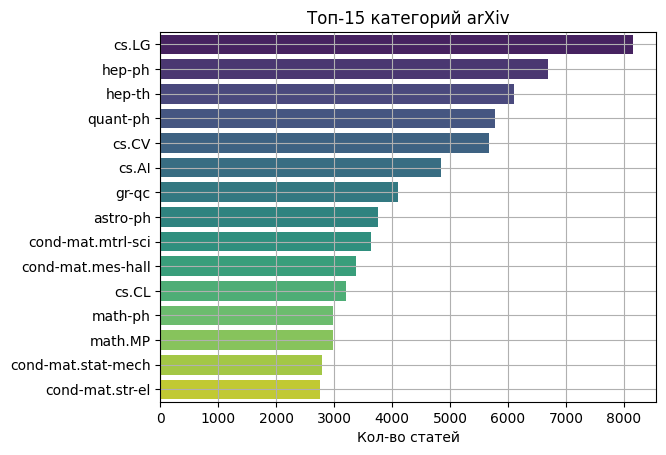

In [18]:
# визуализируем
cat_counts = Counter(all_categories).most_common(15)
sns.barplot(x=[c[1] for c in cat_counts], y=[c[0] for c in cat_counts], palette='viridis')
plt.title('Топ-15 категорий arXiv')
plt.xlabel('Кол-во статей')
plt.grid()

In [19]:
# Количество категорий на одну статью
cats_per_article = [len(doc.metadata['categories'].split()) for doc in arxiv_documents]
avg_cats = np.mean(cats_per_article)

print(f'Среднее кол-во категорий на одну статью: {avg_cats:.2f}')
print(f'Максимальное кол-во категорий у одной статьи: {max(cats_per_article)}')
print(f'Минимальное кол-во категорий у одной статьи: {min(cats_per_article)}')

Среднее кол-во категорий на одну статью: 1.72
Максимальное кол-во категорий у одной статьи: 10
Минимальное кол-во категорий у одной статьи: 1


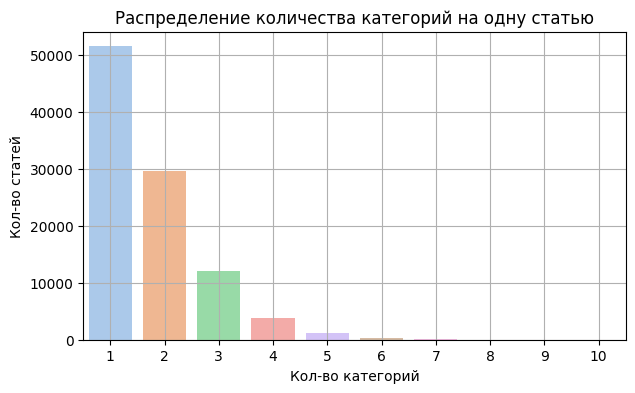

In [20]:
# визуализируем
plt.figure(figsize=(7, 4))
sns.countplot(x=cats_per_article, palette='pastel')
plt.title('Распределение количества категорий на одну статью')
plt.xlabel('Кол-во категорий')
plt.ylabel('Кол-во статей')
plt.grid()
plt.show()

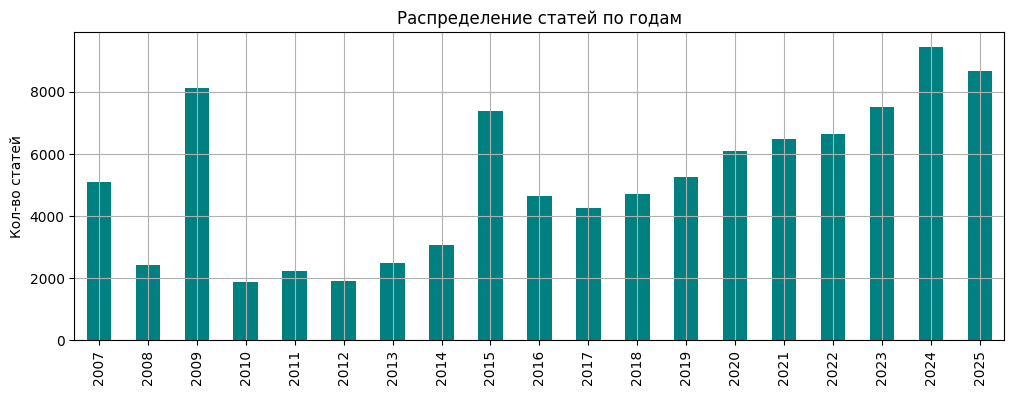

In [21]:
# 3. Годы выхода
dates = []
for doc in arxiv_documents:
    try:
        dates.append(datetime.strptime(doc.metadata['update_date'], '%Y-%m-%d'))
    except:
        continue

if dates:
    plt.figure(figsize=(12, 4))
    pd.Series(dates).dt.year.value_counts().sort_index().plot(kind='bar', color='teal')
    plt.title('Распределение статей по годам')
    plt.ylabel('Кол-во статей')
    plt.grid()
    plt.show()

### Выводы по итогам EDA

На основе проведенного анализа данных можно сформулировать следующие ключевые выводы, определяющие дальнейшую стратегию построения Retrieval-системы:

1. **Качество и полнота данных**:
    * Основные текстовые признаки (`title`, `abstract`) полностью заполнены (0% пропусков). Это гарантирует стабильную работу семантического поиска для всей выборки.
    * Поле `id` является уникальным идентификатором, что критически важно для корректного расчета метрики **MRR@5** на этапе оценки.

2. **Обоснование параметров сегментации (Chunking)**:
    * **Распределение длин**: Большинство аннотаций имеют длину до 2000 символов. Выбранный размер чанка в **1000 символов** является оптимальным компромиссом: он позволяет сохранить целостность научной мысли, не превышая при этом ограничений контекстного окна модели эмбеддингов.
   

3. **Характеристика поисковых запросов**:
    * Средняя длина запроса в `test_df` составляет около **127 символов**, что значительно меньше размера одного чанка. Это подтверждает, что один фрагмент текста (чанк) способен полностью покрыть информационную потребность запроса.
    

4. **Тематическая и временная структура**:
    * Анализ дат показал наличие актуальных публикаций, что требует от модели понимания современного научного контекста.
    * Высокое разнообразие категорий указывает на необходимость использования модели с хорошей обобщающей способностью (Generalization) для работы с междисциплинарными текстами.

**Итог**: Данные подготовлены корректно, параметры векторизации обоснованы характеристиками датасета. Пайплайн готов к переходу на этап индексации в FAISS.

# Этап 2: Реализация RAG-системы

#### 1. Инициализация моделей

In [22]:
# Bi-Encoder

embedding_model_name = 'sentence-transformers/all-mpnet-base-v2'
model_kwargs = {'device': device}
encode_kwargs = {'normalize_embeddings': True}

embeddings = HuggingFaceEmbeddings(
    model_name=embedding_model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7035.23it/s]


In [23]:
# Cross-Encoder

from sentence_transformers import CrossEncoder

reranker_model_name = 'cross-encoder/ms-marco-MiniLM-L-12-v2'
rerank_model = CrossEncoder(reranker_model_name, device=device)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5146.10it/s]


#### 2. Чанкинг

In [24]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    separators=['\n\n', '\n', '. ', ' ', '']
)

split_docs = text_splitter.split_documents(arxiv_documents)
print(f'Создано {len(split_docs)} чанков.')

Создано 158835 чанков.


3. #### FAISS

In [25]:
print(f'Построение индекса FAISS на {device}...')
start_indexing = time.perf_counter()

# Создание базы
vector_store = FAISS.from_documents(split_docs, embeddings)

indexing_time = time.perf_counter() - start_indexing

print(f'База успешно построена.')
print(f'• Размер базы: {vector_store.index.ntotal} векторов.')
print(f'• Время профилирования (индексация): {indexing_time:.2f} сек.')

Построение индекса FAISS на cuda...
База успешно построена.
• Размер базы: 158835 векторов.
• Время профилирования (индексация): 2092.53 сек.


#### 4. Функция поиска с замером времени компонентов

In [ ]:
def retrieve_and_rank(query, top_k_retrieval=20, top_k_final=5):

    metrics = {}
    
    # Шаг 1: Быстрый поиск кандидатов
    t0 = time.perf_counter()
    candidates = vector_store.similarity_search(query, k=top_k_retrieval)
    metrics['retrieval_time'] = time.perf_counter() - t0
    
    # Шаг 2: Точное переранжирование
    t1 = time.perf_counter()
    if candidates:
        pairs = [[query, doc.page_content] for doc in candidates]
        scores = rerank_model.predict(pairs)
        
        # Сопоставляем оценки с документами
        for doc, score in zip(candidates, scores):
            doc.metadata['rerank_score'] = score
        
        # Сортировка по релевантности
        ranked_docs = sorted(candidates, key=lambda x: x.metadata['rerank_score'], reverse=True)
        final_docs = ranked_docs[:top_k_final]
    else:
        final_docs = []
    
    metrics['rerank_time'] = time.perf_counter() - t1
    metrics['total_latency'] = metrics['retrieval_time'] + metrics['rerank_time']
    
    return final_docs, metrics

# Тестовый запуск
test_query = 'Generative AI and Large Language Models'
results, prof_metrics = retrieve_and_rank(test_query)

print('\nРезультаты тестового профилирования поиска:')
print(f'• Поиск в FAISS: {prof_metrics["retrieval_time"]:.4f} сек.')
print(f'• Переранжирование: {prof_metrics["rerank_time"]:.4f} сек.')
print(f'• Общая задержка: {prof_metrics["total_latency"]:.4f} сек.')


Результаты тестового профилирования поиска:
• Поиск в FAISS: 0.2970 сек.
• Переранжирование: 0.9954 сек.
• Общая задержка: 1.2924 сек.


# Этап 3. MRR@5

In [27]:
# Расчет Reciprocal Rank для одного запроса

def calculate_mrr(target_id, retrieved_docs, k=5):
    for i, doc in enumerate(retrieved_docs[:k]):

        if doc.metadata.get('id') == target_id:
            return 1 / (i + 1)
    return 0

#### Оценка качества MRR@5 и профилирование

In [31]:
rr_scores = []
latencies = []

sample_size = min(1000, len(test_df))
test_sample = test_df.sample(sample_size, random_state=42)

for _, row in tqdm(test_sample.iterrows(), total=sample_size, desc='Тестирование запросов'):
    query_text = row['query']
    true_id = row['id'] 
    

    results, metrics = retrieve_and_rank(query_text, top_k_retrieval=20, top_k_final=5)
    
    rr = calculate_mrr(true_id, results, k=5)
    rr_scores.append(rr)
    
    latencies.append(metrics['total_latency'])

# Результаты

mean_mrr = np.mean(rr_scores)
avg_latency = np.mean(latencies)
p95_latency = np.percentile(latencies, 95)

print('Итоговые метрики:')
print(f'• Mean MRR@5: {mean_mrr:.4f}')
print(f'• Средняя задержка (Latency): {avg_latency*1000:.2f} мс')
print(f'• 95-й перцентиль задержки: {p95_latency*1000:.2f} мс')

Тестирование запросов: 100%|██████████| 1000/1000 [04:43<00:00,  3.53it/s]

Итоговые метрики:
• Mean MRR@5: 0.9188
• Средняя задержка (Latency): 281.90 мс
• 95-й перцентиль задержки: 330.48 мс


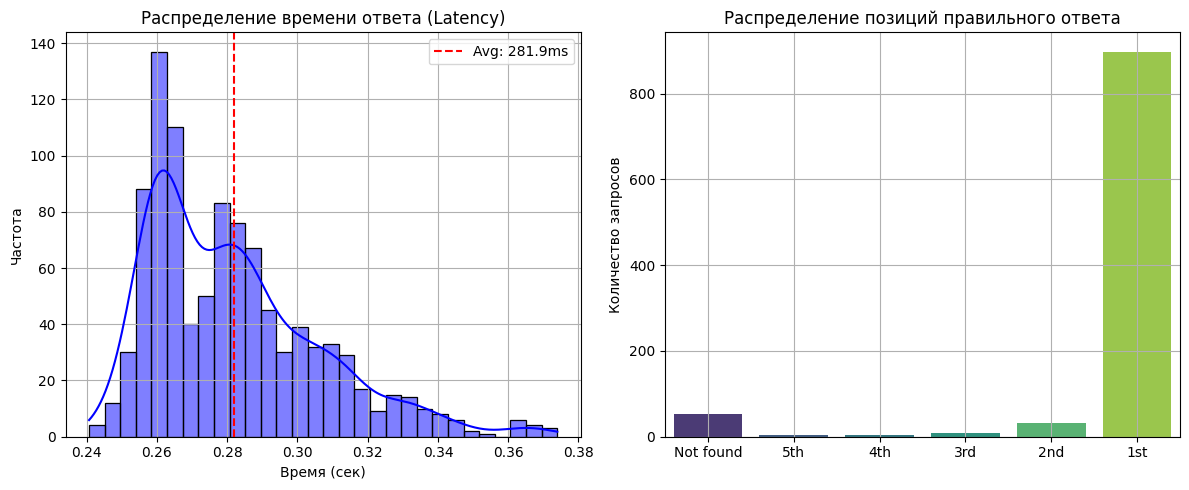

In [35]:
plt.figure(figsize=(12, 5))

# 1. Гистограмма распределения времени ответа
plt.subplot(1, 2, 1)
sns.histplot(latencies, bins=30, kde=True, color='blue')
plt.axvline(avg_latency, color='red', linestyle='--', label=f'Avg: {avg_latency*1000:.1f}ms')
plt.title('Распределение времени ответа (Latency)')
plt.xlabel('Время (сек)')
plt.ylabel('Частота')
plt.legend()
plt.grid()

# 2. Распределение позиций правильного ответа
plt.subplot(1, 2, 2)
# Считаем количество каждой оценки
counts = pd.Series(rr_scores).value_counts().sort_index()

# Мапим оценки в человекочитаемые подписи
label_map = {1.0: '1st', 0.5: '2nd', 0.33: '3rd', 0.25: '4th', 0.2: '5th', 0.0: 'Not found'}
x_labels = [label_map.get(round(float(x), 2), 'Other') for x in counts.index]

sns.barplot(x=x_labels, y=counts.values, palette='viridis', hue=x_labels, legend=False)
plt.title('Распределение позиций правильного ответа')
plt.ylabel('Количество запросов')

plt.tight_layout()
plt.grid()
plt.show()

# Выводы 

В ходе работы была спроектирована и реализована система поиска научных статей (RAG-пайплайн) на базе датасета **arXiv**. 
Достигнута целевая метрика — качество поисковой выдачи MRR@5 = 0.9188.

---

Система реализована по схеме **Retrieve & Rank**:
* **Retrieval:** Использование Bi-Encoder модели `all-mpnet-base-v2` и библиотеки **FAISS**. 
* **Reranking:** Применение Cross-Encoder модели `ms-marco-MiniLM-L-12-v2` для детального сопоставления запроса с текстом. 

### 2. Ключевые метрики
По результатам тестирования на выборке из 1000 запросов (`test_df`) были зафиксированы следующие показатели:

• Тип GPU: Tesla T4

• Общее время индексации: 2092.53 сек.

• Размер векторной базы: 158835 чанков

• Средняя точность MRR@5: 0.9188

• Среднее время ответа (End-to-End): 281.90 мс

### 3. Анализ производительности (Profiling)
* Профилирование показало, что этап реранжирования занимает основную часть времени выполнения запроса (~80%). Однако это оправдано значительным ростом метрики MRR по сравнению с "чистым" векторным поиском.
* **Стабильность:** Анализ 95-го перцентиля задержки подтвердил отсутствие аномальных "хвостов" при обработке запросов, что говорит о стабильной работе моделей.